# CulRAG: Retrieval Evaluation (Phase 2)

Scores `VectorRetriever` against a hand-labeled set of (query, relevant_foods)
pairs (`data/eval_queries.json`) using `RAGEvaluator` from `src/evaluator.py`:
Precision@k, Recall@k, and Mean Reciprocal Rank (MRR).

Like notebook 01, this runs without API keys via a deterministic local
fallback embedding, so it's a **retrieval-pipeline sanity check**, not a
claim about production embedding quality. Once real OpenAI/Claude embeddings
and the full IFCT dataset are wired in, re-run this notebook to get the
actual numbers that belong in the paper.

In [1]:
import sys
import json
import math
import os
import zlib
from collections import Counter
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from src.retriever import VectorRetriever
from src.evaluator import RAGEvaluator

df = pd.read_csv(project_root / "data" / "sample_foods.csv")
with open(project_root / "data" / "eval_queries.json") as f:
    test_cases = json.load(f)

print(f"Loaded {len(df)} foods and {len(test_cases)} labeled eval queries")

Loaded 50 foods and 9 labeled eval queries


## 1. Index the knowledge base

In [2]:
EMBEDDING_DIM = 64


def local_hash_embed(text: str):
    """Deterministic (cross-process) fallback embedding (no API key required)."""
    vector = [0.0] * EMBEDDING_DIM
    for word, count in Counter(text.lower().split()).items():
        vector[zlib.crc32(word.encode()) % EMBEDDING_DIM] += count
    norm = math.sqrt(sum(v * v for v in vector)) or 1.0
    return [v / norm for v in vector]


use_openai = bool(os.getenv("OPENAI_API_KEY"))
embedding_function = None if use_openai else local_hash_embed
print(f"Using {'OpenAI embeddings' if use_openai else 'local hashing fallback embedding'}")

retriever = VectorRetriever(
    vector_db_type="chroma",
    index_name="culrag_eval_demo",
    embedding_function=embedding_function,
    persist_directory=None,
)
retriever.initialize_db()

documents = [
    f"{row.food_name}: {row.calories} kcal, protein {row.protein_g}g, "
    f"carbs {row.carbs_g}g, fat {row.fat_g}g, region {row.region}, "
    f"ayurvedic type {row.ayurvedic_type}, cooking method {row.cooking_method}"
    for row in df.itertuples()
]
metadatas = df.to_dict("records")
retriever.index_documents(documents, metadatas=metadatas)
retriever.get_stats()

Using local hashing fallback embedding


/Users/kavya/culrag/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


{'index_name': 'culrag_eval_demo',
 'vector_db_type': 'chroma',
 'count': 50,
 'dimension': 1536}

## 2. Run the evaluation

In [3]:
evaluator = RAGEvaluator()
report = evaluator.evaluate_retrieval(retriever, test_cases, k=5)
print(evaluator.generate_report(report))

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


CulRAG Evaluation Report
Retrieval (k=5):
  Mean Precision@5: 0.133
  Mean Recall@5:    0.185
  Mean Reciprocal Rank: 0.217

Evaluated 9 queries.


## 3. Per-query breakdown

In [4]:
per_query_df = pd.DataFrame(report["per_query"])[
    ["query", "precision_at_k", "recall_at_k", "reciprocal_rank"]
]
per_query_df

,query,precision_at_k,recall_at_k,reciprocal_rank
0,high protein vegetarian snack,0.2,0.250000,0.20
1,South Indian breakfast dish,0.0,0.000000,0.00
2,low calorie clear soup,0.0,0.000000,0.00
3,North Indian lentil curry,0.2,0.250000,0.25
4,Pitta-pacifying Ayurvedic food,0.0,0.000000,0.00
5,sweet dessert,0.0,0.000000,0.00
6,shallow-fried snack,0.4,0.666667,0.50
7,steamed rice-based dish,0.4,0.500000,1.00
8,non-vegetarian curry,0.0,0.000000,0.00


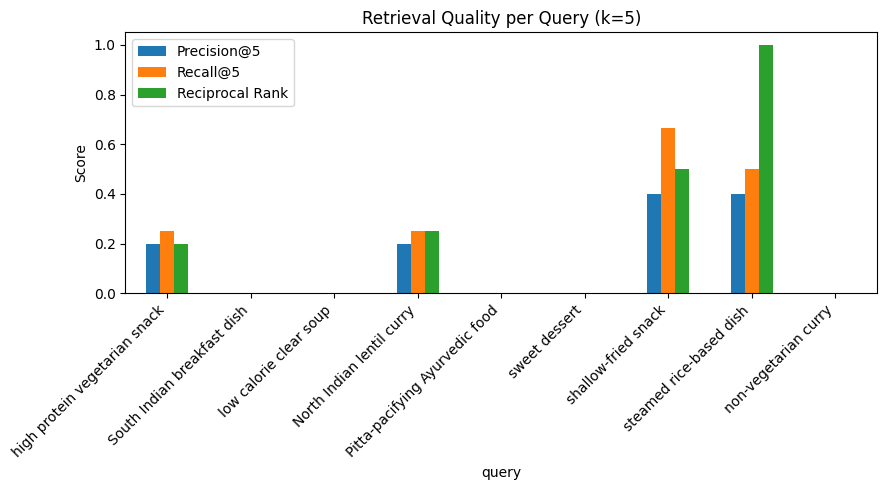

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
per_query_df.set_index("query")[["precision_at_k", "recall_at_k", "reciprocal_rank"]].plot(
    kind="bar", ax=ax
)
ax.set_title("Retrieval Quality per Query (k=5)")
ax.set_ylabel("Score")
ax.legend(["Precision@5", "Recall@5", "Reciprocal Rank"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
retriever.delete_index()

## 4. Findings & next steps

**With the local hashing fallback embedding**, retrieval quality is a
word-overlap proxy, not semantic similarity — the numbers above measure
whether the *pipeline* (index -> query -> rank -> score) is wired correctly,
not whether the *embedding model* understands Indian food semantics.

**To get meaningful numbers for the paper:**
- Set `OPENAI_API_KEY` and re-run — this notebook automatically switches to
  real embeddings when the key is present.
- Expand `data/eval_queries.json` well beyond 9 queries once Vartan's full
  IFCT dataset lands; labeled ground truth should scale with corpus size.
- Track these metrics per model/embedding choice as an ablation table for
  the RAG hyperparameter section of the paper.
- Pair retrieval metrics here with `RAGEvaluator.evaluate_batch()` (in
  `src/evaluator.py`) once end-to-end LLM calls are budgeted, to report
  hallucination rate and constraint pass rate alongside retrieval quality.